In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## **Modeling Setup**

In [3]:
df = pd.read_csv('data_cleaned.csv')
df['Log_Price'] = np.log(df['Price'])

cat_cols = ['Apartment type', 'Region', 'Renovation']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

display(df.head(), df.shape)

,Price,Metro station,Minutes to metro,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Log_Price,Apartment type_Secondary,Region_Moscow region,Renovation_Designer,Renovation_European-style renovation,Renovation_Without renovation
0,6300000.0,Опалиха,6.0,1.0,30.6,11.1,8.5,25.0,25,15.656060,1,1,0,0,0
1,9000000.0,Павшино,2.0,1.0,49.2,20.0,10.0,6.0,15,16.012735,1,1,0,1,0
2,11090000.0,Мякинино,14.0,1.0,44.7,16.2,13.1,10.0,25,16.221554,1,1,0,0,0
3,8300000.0,Строгино,8.0,1.0,35.1,16.0,11.0,12.0,33,15.931766,1,1,0,1,0
4,6450000.0,Опалиха,6.0,1.0,37.7,15.2,4.0,5.0,5,15.679591,1,1,0,0,1


(18374, 15)

In [4]:
X = df.drop(columns = ['Price', 'Log_Price', 'Metro station'])
y = df['Log_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set:  {X_train.shape}")
print(f"Test set:      {X_test.shape}")
print(f"Total features: {X_train.shape[1]}")
print(f"\nFeature names:\n{list(X.columns)}")

Training set:  (14699, 12)
Test set:      (3675, 12)
Total features: 12

Feature names:
['Minutes to metro', 'Number of rooms', 'Area', 'Living area', 'Kitchen area', 'Floor', 'Number of floors', 'Apartment type_Secondary', 'Region_Moscow region', 'Renovation_Designer', 'Renovation_European-style renovation', 'Renovation_Without renovation']


## **OLS Linear Regression (Baseline)**

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

# Shared preprocessor -- used by OLS, Lasso, and Ridge so all coefficients are on the same scale
numeric_cols = ['Minutes to metro', 'Number of rooms', 'Area',
                'Living area', 'Kitchen area', 'Floor', 'Number of floors']

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[('num', numeric_transformer, numeric_cols)],
    remainder='passthrough'
)

# OLS fit through the same preprocessor so coefficients are on the same scale as Lasso/Ridge
ols_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('ols', LinearRegression())
])

ols_pipeline.fit(X_train, y_train)

y_pred_ols_train = ols_pipeline.predict(X_train)
y_pred_ols_test  = ols_pipeline.predict(X_test)

train_r2_score = r2_score(y_train, y_pred_ols_train)
test_r2_score  = r2_score(y_test, y_pred_ols_test)
rmse_log       = np.sqrt(mean_squared_error(y_test, y_pred_ols_test))
mae_rub        = mean_absolute_error(np.exp(y_test), np.exp(y_pred_ols_test))
mape_ols       = mean_absolute_percentage_error(np.exp(y_test), np.exp(y_pred_ols_test)) * 100

print("=== OLS Linear Regression ===")
print(f"Train R²:         {train_r2_score:.4f}")
print(f"Test R²:          {test_r2_score:.4f}")
print(f"RMSE (log):       {rmse_log:.4f}")
print(f"MAE (₽):          {mae_rub:,.0f}")
print(f"MAPE:             {mape_ols:.2f}%")

=== OLS Linear Regression ===
Train R²:         0.8599
Test R²:          0.8694
RMSE (log):       0.3888
MAE (₽):          26,525,122
MAPE:             28.45%


In [6]:
# Feature name order after ColumnTransformer: numeric (scaled) first, then dummies (passthrough)
dummy_cols = [col for col in X_train.columns if col not in numeric_cols]
feature_names_scaled = numeric_cols + dummy_cols

ols_coef_series = pd.Series(ols_pipeline.named_steps['ols'].coef_, index=feature_names_scaled)
print(ols_coef_series.round(4))

Minutes to metro                       -0.0889
Number of rooms                         0.2209
Area                                    0.3946
Living area                             0.0209
Kitchen area                            0.1104
Floor                                  -0.0015
Number of floors                        0.0125
Apartment type_Secondary                0.3314
Region_Moscow region                   -0.4331
Renovation_Designer                     0.6651
Renovation_European-style renovation    0.2618
Renovation_Without renovation           0.4052
dtype: float64


In [7]:
coef_df_ols = ols_coef_series.abs().sort_values(ascending=False)
print("Top 5 features by |coefficient| (standardized scale):")
print(coef_df_ols.head(5))

Top 5 features by |coefficient| (standardized scale):
Renovation_Designer              0.665149
Region_Moscow region             0.433070
Renovation_Without renovation    0.405167
Area                             0.394605
Apartment type_Secondary         0.331429
dtype: float64


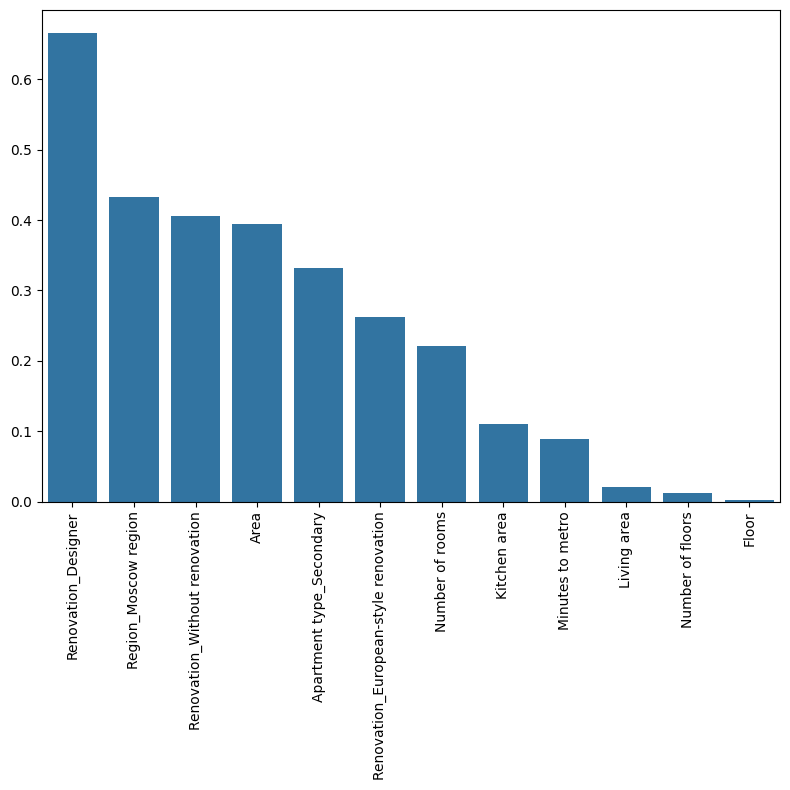

In [8]:
plt.figure(figsize=(8, 8))
sns.barplot(coef_df_ols)
plt.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

### OLS Regression -- Findings

A standard OLS linear regression on all 12 features gives a solid baseline. The model explains about 87% of the variation in log-transformed apartment prices on the held-out test set (Test R² = 0.87), with almost no gap from training (Train R² = 0.86). That small spread suggests the model generalizes well and is not overfitting. In price terms, predictions are off by about 26.5M rubles on average (MAE) and 28.5% on a percentage basis (MAPE).

With all features on a standardized scale, the coefficient picture is clear. Renovation quality and location are the two dominant price drivers. Designer renovation commands the largest premium (+0.67 log units) relative to the baseline of cosmetic renovation. Being in Moscow city rather than the surrounding Moscow region also adds a lot of value -- the Region_Moscow region coefficient is -0.43, meaning suburban listings are penalized that much relative to city apartments. Area is right behind at +0.39, confirming that size matters a lot once everything is on a fair footing.

A few things worth noting about reference categories. With drop_first=True, the baselines are Cosmetic renovation, Moscow city, and New building apartment type. So coefficients for renovation are all relative to cosmetic -- and every other renovation type is priced higher than cosmetic. The "Without renovation" coefficient (+0.41) looks counterintuitive at first, but cosmetic renovation appears to be the lowest-quality finish category in this dataset, so unrenovated apartments still price above it. Similarly, secondary market apartments are priced above new buildings on average (+0.33), likely because secondary stock tends to sit in more established, central Moscow neighborhoods.

Floor is essentially zero (-0.002) and will almost certainly get dropped by regularized models. The log-scale RMSE of 0.39 is the primary accuracy metric throughout -- ruble-denominated numbers (MAE, MAPE) are useful context but get pulled around by high-value listings.

# **Lasso Model**

In [9]:
from sklearn.linear_model import LassoCV

In [10]:
lasso_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('lasso', LassoCV(
        cv=10,
        random_state=42,
        max_iter=10000
    ))
])

lasso_pipeline.fit(X_train, y_train)

y_pred_lasso_train = lasso_pipeline.predict(X_train)
y_pred_lasso_test  = lasso_pipeline.predict(X_test)

# Metrics
lasso_train_r2 = r2_score(y_train, y_pred_lasso_train)
lasso_test_r2  = r2_score(y_test, y_pred_lasso_test)
lasso_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))
lasso_mae_rub  = mean_absolute_error(np.exp(y_test), np.exp(y_pred_lasso_test))
lasso_mape     = mean_absolute_percentage_error(np.exp(y_test), np.exp(y_pred_lasso_test)) * 100

best_alpha  = lasso_pipeline.named_steps['lasso'].alpha_
lasso_coefs = lasso_pipeline.named_steps['lasso'].coef_
n_zeroed    = np.sum(lasso_coefs == 0)
n_kept      = np.sum(lasso_coefs != 0)

print("=== Lasso Regression ===")
print(f"Best alpha:       {best_alpha:.6f}")
print(f"Features kept:    {n_kept} / {X_train.shape[1]}")
print(f"Features zeroed:  {n_zeroed}")
print(f"Train R²:         {lasso_train_r2:.4f}")
print(f"Test R²:          {lasso_test_r2:.4f}")
print(f"RMSE (log):       {lasso_rmse_log:.4f}")
print(f"MAE (₽):          {lasso_mae_rub:,.0f}")
print(f"MAPE:             {lasso_mape:.2f}%")

coef_series = pd.Series(lasso_coefs, index=feature_names_scaled)
print("\nZeroed out features:")
print(coef_series[coef_series == 0].index.tolist())
print("\nKept features (by |coefficient|):")
print(coef_series[coef_series != 0].abs().sort_values(ascending=False))

=== Lasso Regression ===
Best alpha:       0.000852
Features kept:    11 / 12
Features zeroed:  1
Train R²:         0.8599
Test R²:          0.8694
RMSE (log):       0.3889
MAE (₽):          26,833,143
MAPE:             28.41%

Zeroed out features:
['Floor']

Kept features (by |coefficient|):
Renovation_Designer                     0.647620
Region_Moscow region                    0.432241
Area                                    0.396803
Renovation_Without renovation           0.388005
Apartment type_Secondary                0.338869
Renovation_European-style renovation    0.247459
Number of rooms                         0.220170
Kitchen area                            0.110633
Minutes to metro                        0.088055
Living area                             0.020605
Number of floors                        0.011610
dtype: float64


## Lasso Regression -- Findings

Lasso with 10-fold cross-validation selected alpha = 0.000852 and zeroed out exactly one feature: Floor. This was predictable -- Floor had nearly zero correlation with price in the EDA and a near-zero coefficient in OLS (-0.002). Every other feature was kept, which tells us the original feature set was already lean. There was nothing wasteful to trim.

Performance is essentially identical to OLS (Test R² = 0.87, RMSE log = 0.39, MAPE = 28%), which makes sense when only one near-zero feature gets dropped. The value of Lasso here is confirmation, not accuracy gain.

The bigger story is what the coefficient table now shows. Once all models are on a standardized scale, OLS and Lasso agree on nearly every coefficient. Area is 0.395 in OLS and 0.397 in Lasso. Renovation_Designer is 0.665 vs 0.648. Region_Moscow region is -0.433 vs -0.432. The differences are rounding noise. Lasso slightly shrinks coefficients for features with more redundancy (like Living area staying small at 0.02 while Area gets 0.40), but both models tell the same story. The takeaway here is not that regularization "fixed" anything -- it is that the features are genuinely informative and the coefficient estimates are stable across modeling approaches.

# **Ridge Model**

In [11]:
from sklearn.linear_model import RidgeCV

ridge_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('ridge', RidgeCV(
        alphas=np.logspace(-3, 3, 100),
        cv=10
    ))
])

ridge_pipeline.fit(X_train, y_train)

y_pred_ridge_train = ridge_pipeline.predict(X_train)
y_pred_ridge_test  = ridge_pipeline.predict(X_test)

# Metrics
ridge_train_r2 = r2_score(y_train, y_pred_ridge_train)
ridge_test_r2  = r2_score(y_test, y_pred_ridge_test)
ridge_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))
ridge_mae_rub  = mean_absolute_error(np.exp(y_test), np.exp(y_pred_ridge_test))
ridge_mape     = mean_absolute_percentage_error(np.exp(y_test), np.exp(y_pred_ridge_test)) * 100

best_alpha_ridge = ridge_pipeline.named_steps['ridge'].alpha_
ridge_coefs      = ridge_pipeline.named_steps['ridge'].coef_

print("=== Ridge Regression ===")
print(f"Best alpha:        {best_alpha_ridge:.4f}")
print(f"Train R²:          {ridge_train_r2:.4f}")
print(f"Test R²:           {ridge_test_r2:.4f}")
print(f"RMSE (log):        {ridge_rmse_log:.4f}")
print(f"MAE (₽):           {ridge_mae_rub:,.0f}")
print(f"MAPE:              {ridge_mape:.2f}%")

# Coefficient comparison -- all three models on the same standardized scale
coef_compare = pd.DataFrame({
    'OLS':   ols_pipeline.named_steps['ols'].coef_,
    'Lasso': lasso_pipeline.named_steps['lasso'].coef_,
    'Ridge': ridge_coefs
}, index=feature_names_scaled).round(4)

print("\nCoefficient comparison (standardized scale -- all models):")
print(coef_compare)

=== Ridge Regression ===
Best alpha:        6.5793
Train R²:          0.8599
Test R²:           0.8694
RMSE (log):        0.3888
MAE (₽):           26,468,105
MAPE:              28.41%

Coefficient comparison (standardized scale -- all models):
                                         OLS   Lasso   Ridge
Minutes to metro                     -0.0889 -0.0881 -0.0889
Number of rooms                       0.2209  0.2202  0.2208
Area                                  0.3946  0.3968  0.3938
Living area                           0.0209  0.0206  0.0221
Kitchen area                          0.1104  0.1106  0.1109
Floor                                -0.0015 -0.0000 -0.0015
Number of floors                      0.0125  0.0116  0.0127
Apartment type_Secondary              0.3314  0.3389  0.3337
Region_Moscow region                 -0.4331 -0.4322 -0.4327
Renovation_Designer                   0.6651  0.6476  0.6598
Renovation_European-style renovation  0.2618  0.2475  0.2585
Renovation_Without reno

## Ridge Regression -- Findings

Ridge with 10-fold cross-validation landed on alpha = 6.58. Unlike Lasso, Ridge keeps all 12 features -- it shrinks coefficients toward zero but never eliminates them. Floor survives at -0.0015, about the same as OLS, which again confirms it carries almost no signal.

Predictive accuracy matches OLS and Lasso exactly (Test R² = 0.87, RMSE log = 0.39, MAPE = 28%). All three linear models are in agreement on how well this feature set can predict price.

The coefficient comparison table is the main result here. Across all three models, every coefficient is nearly identical. OLS, Lasso, and Ridge all agree: Area is around 0.39-0.40, Designer renovation is 0.65-0.67, Moscow city vs. region is 0.43, no renovation vs. cosmetic is 0.39-0.41. The largest gap anywhere in the table is about 0.02, which is well within noise.

This has an important implication for interpretation. The previous version of this analysis attributed the difference between raw OLS and regularized model coefficients to multicollinearity -- specifically, that Area appeared to jump from near-zero to 0.40 when regularization was applied. That was a scaling artifact. Raw OLS coefficients are in original units (per m², per floor, etc.), while Lasso and Ridge were fit on standardized features. Once OLS is put on the same standardized scale, it matches the regularized models almost exactly. The linear model story is straightforward: the feature set is well-conditioned, coefficient estimates are stable, and regularization is not doing any heavy lifting here beyond minor shrinkage and Lasso's cleanup of Floor.

# **Decision Tree**

In [12]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Initial decision tree -- fully grown, no hyperparameter constraints
dt_initial = DecisionTreeRegressor(random_state=42)
dt_initial.fit(X_train, y_train)

y_pred_dt_initial_train = dt_initial.predict(X_train)
y_pred_dt_initial_test  = dt_initial.predict(X_test)

dt_initial_train_r2 = r2_score(y_train, y_pred_dt_initial_train)
dt_initial_test_r2  = r2_score(y_test, y_pred_dt_initial_test)
dt_initial_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_dt_initial_test))
dt_initial_mae_rub  = mean_absolute_error(np.exp(y_test), np.exp(y_pred_dt_initial_test))
dt_initial_mape     = mean_absolute_percentage_error(np.exp(y_test), np.exp(y_pred_dt_initial_test)) * 100

print("=== Initial Decision Tree (Untuned) ===")
print(f"Train R²:         {dt_initial_train_r2:.4f}")
print(f"Test R²:          {dt_initial_test_r2:.4f}")
print(f"RMSE (log):       {dt_initial_rmse_log:.4f}")
print(f"MAE (₽):          {dt_initial_mae_rub:,.0f}")
print(f"MAPE:             {dt_initial_mape:.2f}%")

=== Initial Decision Tree (Untuned) ===
Train R²:         0.9998
Test R²:          0.8868
RMSE (log):       0.3619
MAE (₽):          15,066,946
MAPE:             22.60%


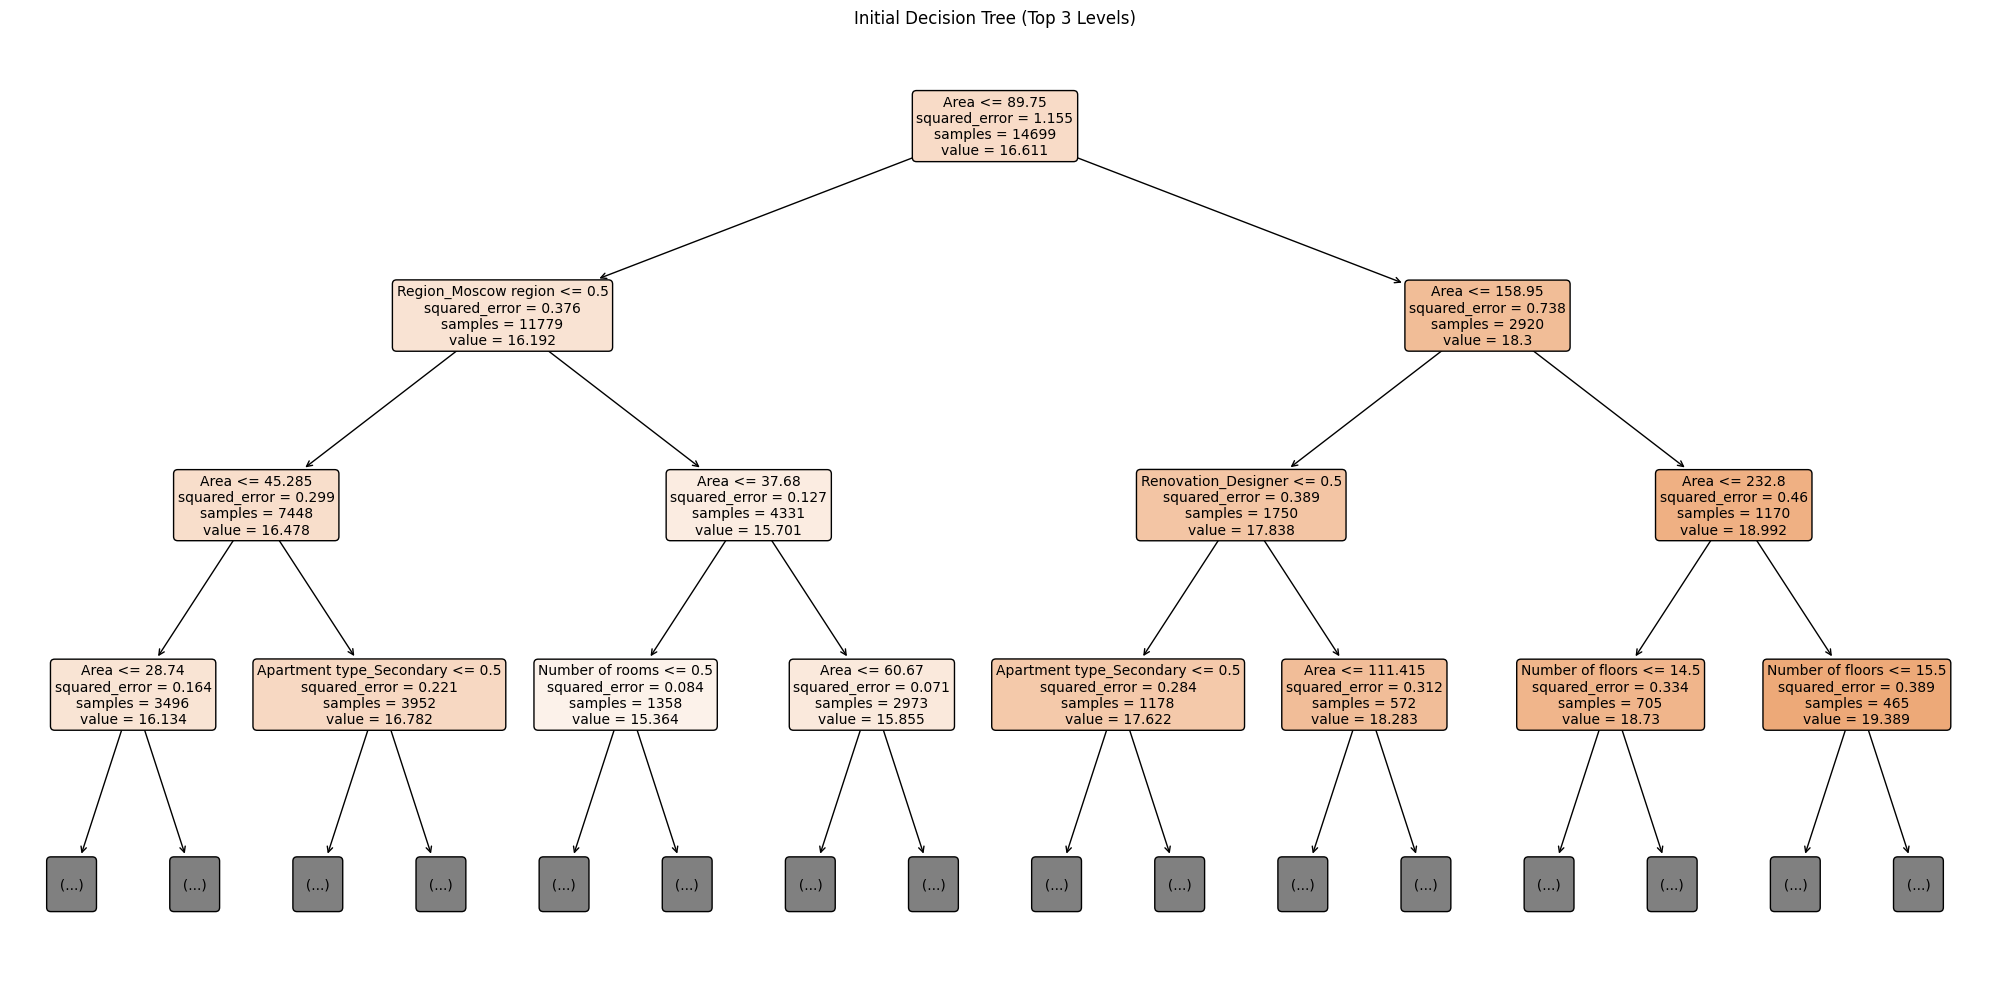

In [13]:
plt.figure(figsize=(20, 10))
plot_tree(dt_initial,
          feature_names=X_train.columns.tolist(),
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=10)
plt.title("Initial Decision Tree (Top 3 Levels)")
plt.tight_layout()
plt.show()

### Initial Decision Tree -- Findings

The untuned decision tree tells an immediate story about overfitting. Train R² is essentially 1.00 -- the tree grew until it memorized every single training example. That is expected behavior for an unconstrained decision tree, and it is a problem. A model that memorizes training data is not learning generalizable patterns, it is just storing answers.

That said, test performance is actually better than all three linear models. The untuned tree hits a Test R² of 0.89 and RMSE (log) of 0.36, compared to 0.87 and 0.39 for OLS, Lasso, and Ridge. The MAE drops from around 26.5M ₽ for the linear models down to 15.1M ₽ here, a meaningful improvement in ruble terms. This suggests the tree is capturing some non-linear structure in the data that the linear models could not -- price relationships that do not follow a straight line across the feature space.

The gap between Train R² (1.00) and Test R² (0.89) is the motivation for tuning. If we can constrain the tree to avoid memorizing noise, we may be able to maintain or improve test accuracy while getting a more trustworthy and interpretable model. That is what GridSearchCV does next.

In [14]:
from sklearn.model_selection import GridSearchCV

# Grid search over depth and leaf constraints -- 45 combinations x 5 folds = 225 fits
dt_param_grid = {
    'max_depth':        [None, 10, 20, 30, 40],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf':  [1, 5, 10]
}

grid_search_dt = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search_dt.fit(X_train, y_train)
dt_optimized = grid_search_dt.best_estimator_

y_pred_dt_opt_train = dt_optimized.predict(X_train)
y_pred_dt_opt_test  = dt_optimized.predict(X_test)

dt_opt_train_r2 = r2_score(y_train, y_pred_dt_opt_train)
dt_opt_test_r2  = r2_score(y_test, y_pred_dt_opt_test)
dt_opt_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_dt_opt_test))
dt_opt_mae_rub  = mean_absolute_error(np.exp(y_test), np.exp(y_pred_dt_opt_test))
dt_opt_mape     = mean_absolute_percentage_error(np.exp(y_test), np.exp(y_pred_dt_opt_test)) * 100

print("=== Tuned Decision Tree (GridSearchCV) ===")
print(f"Best params:      {grid_search_dt.best_params_}")
print(f"Train R²:         {dt_opt_train_r2:.4f}")
print(f"Test R²:          {dt_opt_test_r2:.4f}")
print(f"RMSE (log):       {dt_opt_rmse_log:.4f}")
print(f"MAE (₽):          {dt_opt_mae_rub:,.0f}")
print(f"MAPE:             {dt_opt_mape:.2f}%")

=== Tuned Decision Tree (GridSearchCV) ===
Best params:      {'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}
Train R²:         0.9473
Test R²:          0.9243
RMSE (log):       0.2961
MAE (₽):          13,126,791
MAPE:             18.96%


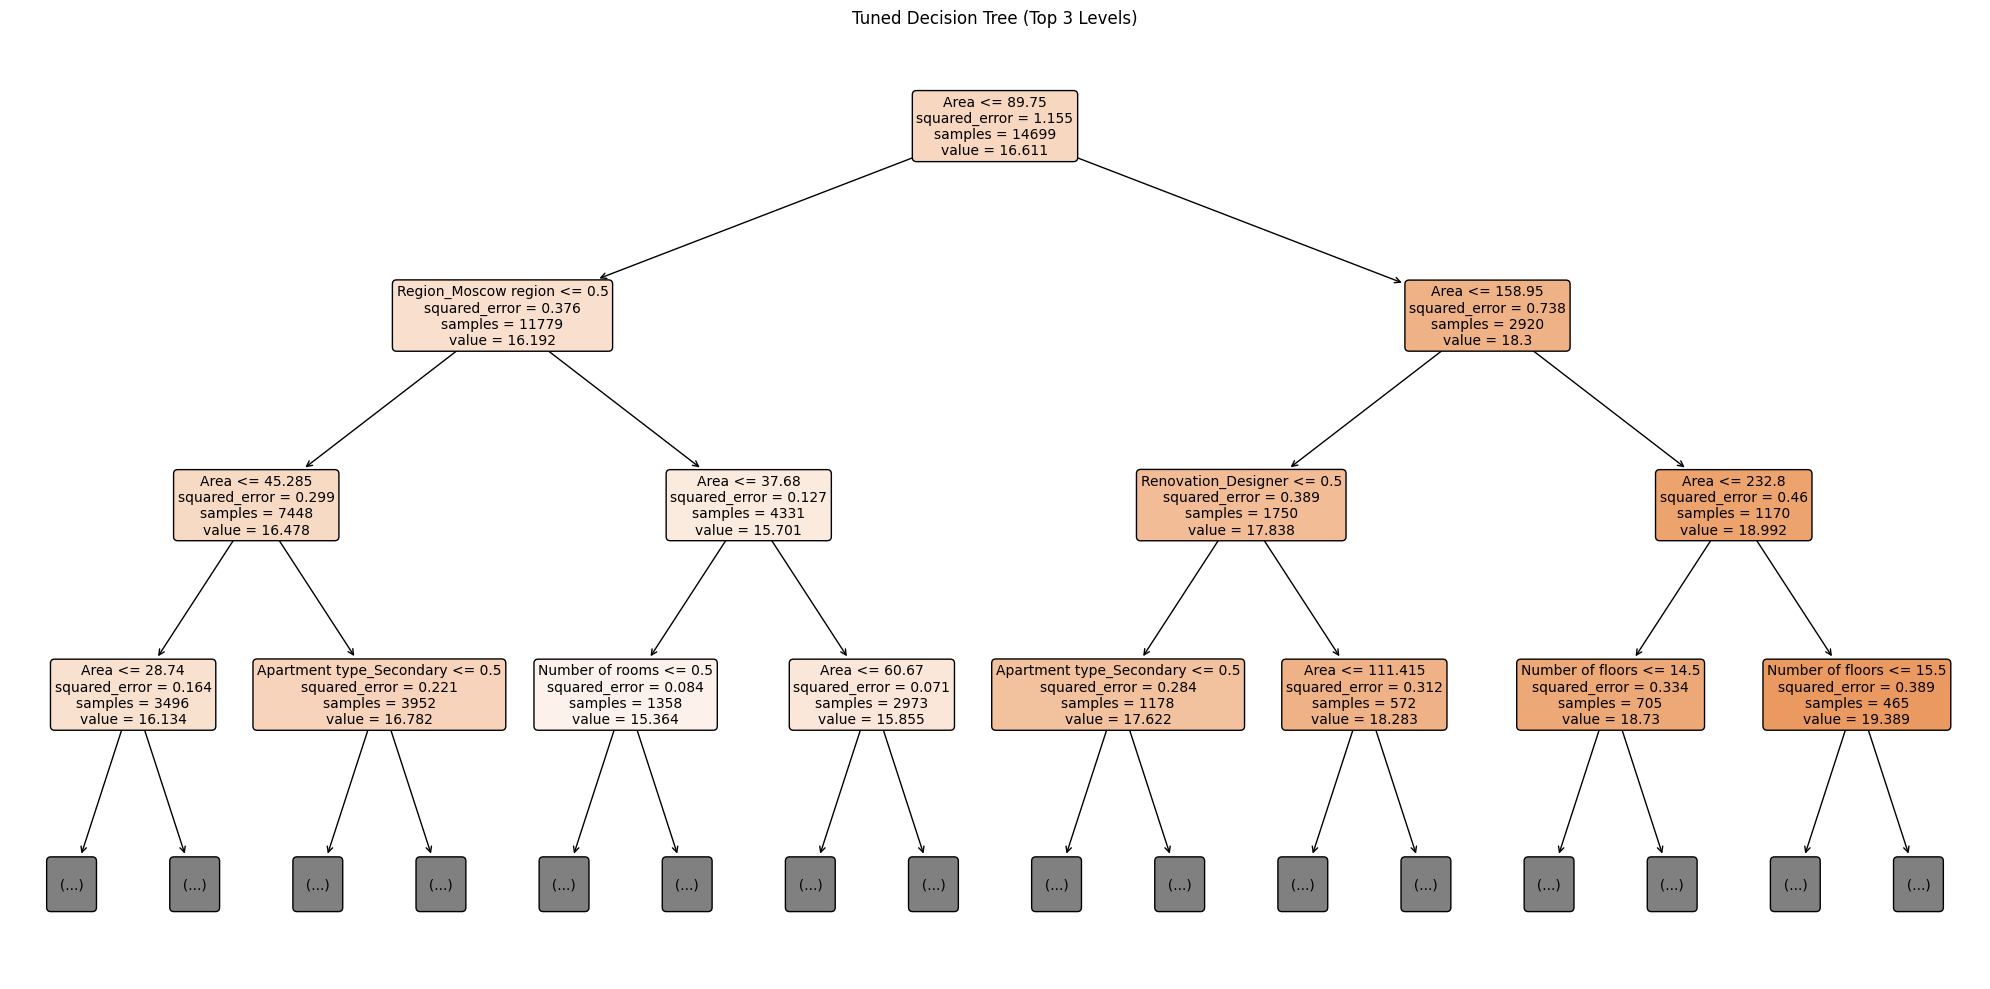

In [15]:
plt.figure(figsize=(20, 10))
plot_tree(dt_optimized,
          feature_names=X_train.columns.tolist(),
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=10)
plt.title("Tuned Decision Tree (Top 3 Levels)")
plt.tight_layout()
plt.show()

### Tuned Decision Tree -- Findings

GridSearchCV selected max_depth=10, min_samples_leaf=10, and min_samples_split=2. Constraining the depth and requiring at least 10 samples at every leaf prevents the tree from memorizing the training data the way the untuned version did.

The results are a clear step up. Test R² went from 0.887 (untuned) to 0.924, and the train/test gap went from 1.00 vs 0.887 down to 0.947 vs 0.924. The model is still slightly overfit, which is normal for a single tree, but it is much more balanced than before. More importantly, it is now well ahead of all three linear models on every metric -- Test R² of 0.924 vs 0.869 for OLS/Lasso/Ridge, RMSE (log) of 0.296 vs 0.389, and MAPE of 19% vs 28%.

This tells us the apartment price data has meaningful non-linear structure. Renovation quality, area, and location do not just add up linearly -- there are interaction effects that a tree can split on directly but a linear model cannot capture. The next step is Random Forest, which builds on this by averaging many trees to reduce the variance that even a tuned single tree still carries.

## **Random Forest**

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', None]
}

random_search_rf = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

random_search_rf.fit(X_train, y_train)
rf_optimized = random_search_rf.best_estimator_

y_pred_rf_train = rf_optimized.predict(X_train)
y_pred_rf_test  = rf_optimized.predict(X_test)

rf_train_r2 = r2_score(y_train, y_pred_rf_train)
rf_test_r2  = r2_score(y_test, y_pred_rf_test)
rf_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
rf_mae_rub  = mean_absolute_error(np.exp(y_test), np.exp(y_pred_rf_test))
rf_mape     = mean_absolute_percentage_error(np.exp(y_test), np.exp(y_pred_rf_test)) * 100

print("=== Tuned Random Forest (RandomizedSearchCV) ===")
print(f"Best params:      {random_search_rf.best_params_}")
print(f"Train R²:         {rf_train_r2:.4f}")
print(f"Test R²:          {rf_test_r2:.4f}")
print(f"RMSE (log):       {rf_rmse_log:.4f}")
print(f"MAE (₽):          {rf_mae_rub:,.0f}")
print(f"MAPE:             {rf_mape:.2f}%")

=== Tuned Random Forest (RandomizedSearchCV) ===
Best params:      {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Train R²:         0.9917
Test R²:          0.9464
RMSE (log):       0.2491
MAE (₽):          11,591,673
MAPE:             15.07%


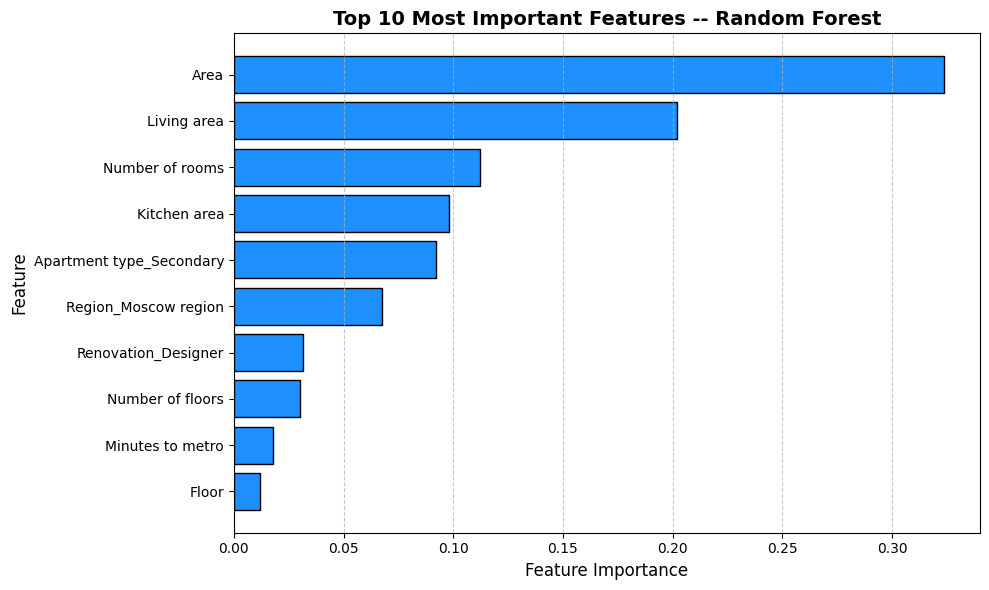

In [17]:
# Feature importances from the Random Forest
importance_df = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': rf_optimized.feature_importances_
}).sort_values('Importance', ascending=True)

top_10 = importance_df.tail(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10['Feature'], top_10['Importance'], color='dodgerblue', edgecolor='black')
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 10 Most Important Features -- Random Forest', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [18]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rf_optimized, X_test, y_test,
    n_repeats=10, random_state=42, scoring='r2', n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature':                X_train.columns,
    'Impurity Importance':    rf_optimized.feature_importances_,
    'Permutation Importance': perm_result.importances_mean
}).sort_values('Permutation Importance', ascending=False).round(4)

print("Feature Importance Comparison -- Impurity (MDI) vs. Permutation:")
print(perm_df.to_string(index=False))

Feature Importance Comparison -- Impurity (MDI) vs. Permutation:
                             Feature  Impurity Importance  Permutation Importance
                                Area               0.3239                  0.3614
            Apartment type_Secondary               0.0923                  0.0900
                Region_Moscow region               0.0673                  0.0715
                         Living area               0.2019                  0.0495
                        Kitchen area               0.0979                  0.0233
                 Renovation_Designer               0.0313                  0.0187
                    Number of floors               0.0300                  0.0186
                     Number of rooms               0.1122                  0.0175
                    Minutes to metro               0.0178                  0.0121
       Renovation_Without renovation               0.0072                  0.0052
Renovation_European-style renovat

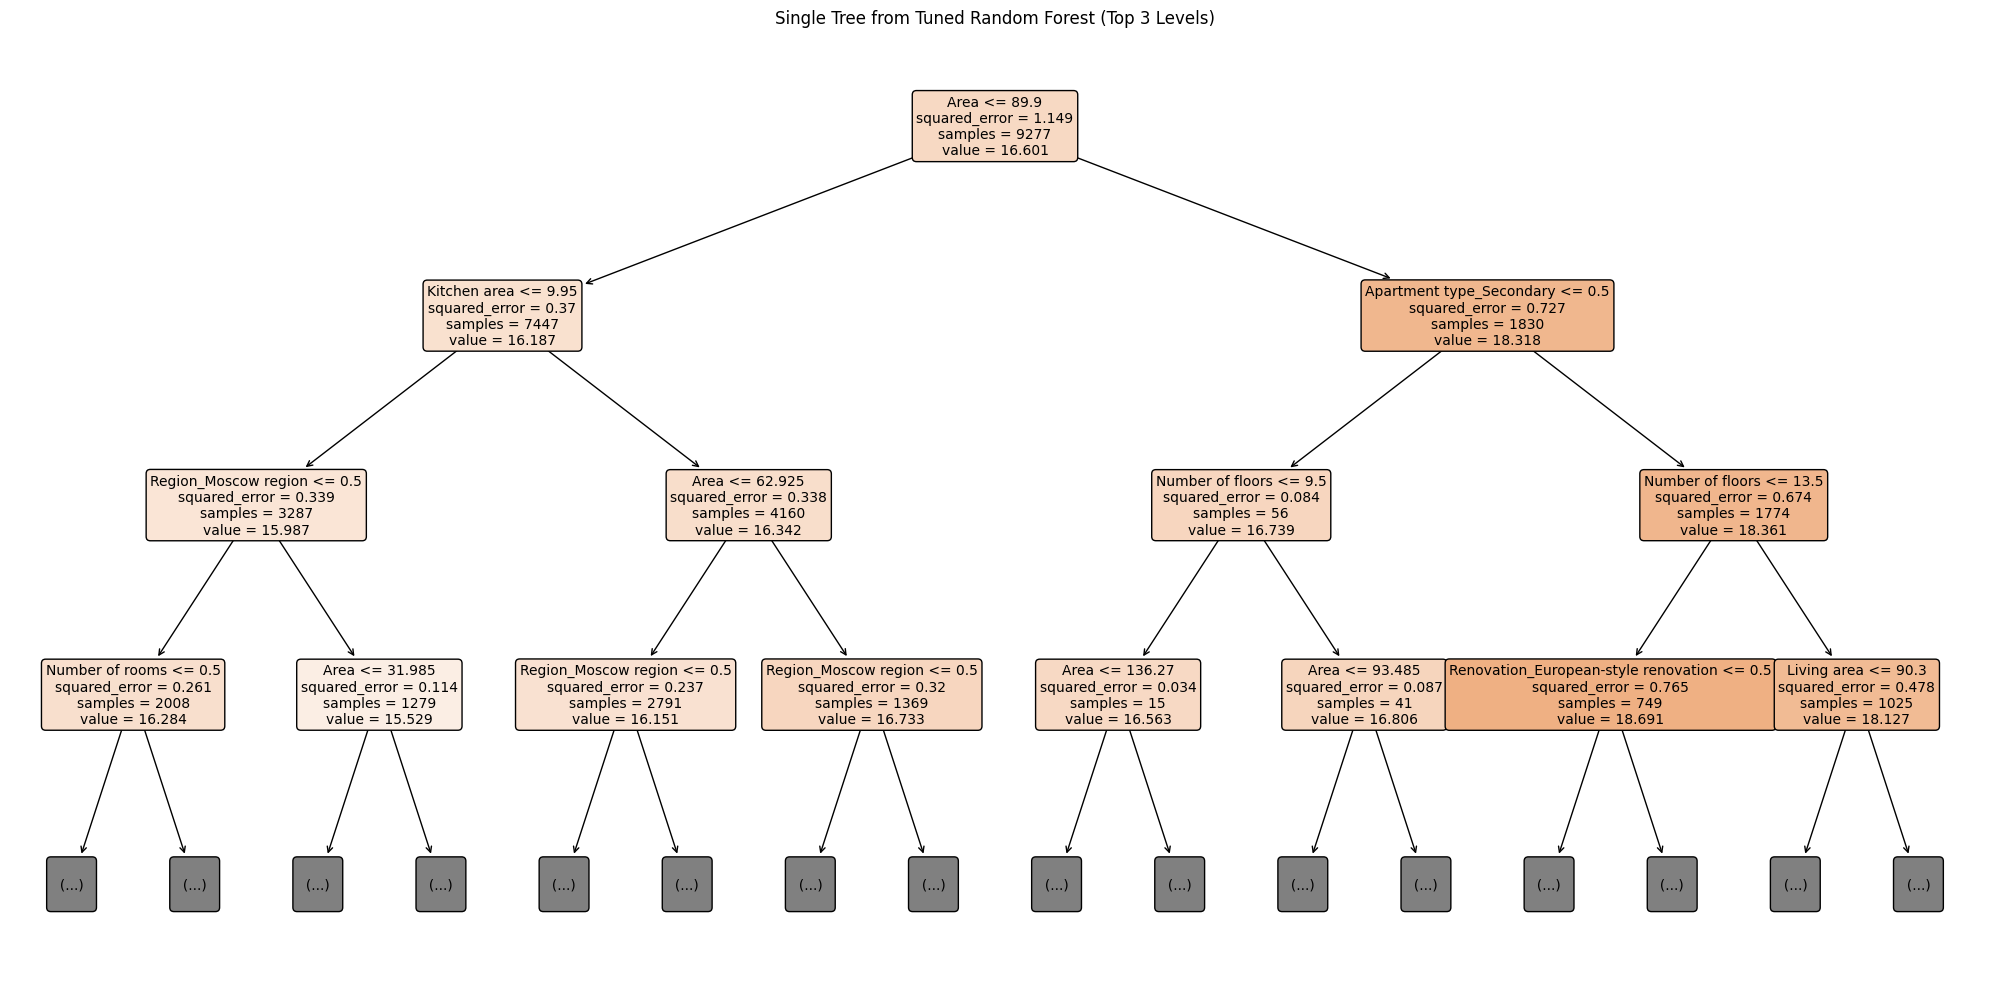

In [21]:
# Visualize a single tree from the forest to illustrate how individual trees split
first_rf_tree = rf_optimized.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(first_rf_tree,
          feature_names=X_train.columns.tolist(),
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=10)
plt.title("Single Tree from Tuned Random Forest (Top 3 Levels)")
plt.tight_layout()
plt.show()

### Random Forest -- Findings

RandomizedSearchCV selected 300 trees, max_depth=20, max_features='sqrt', min_samples_leaf=1, and min_samples_split=2. The 'sqrt' feature setting means each split only considers roughly 3-4 of the 12 features at random, which forces the trees to be diverse and reduces correlation between them. That diversity is the core mechanism behind why ensembles outperform single trees. The search sampled 20 of 324 possible hyperparameter combinations, and n_estimators=300 was at the top of the tested range -- this is a strong first pass, not an exhaustive optimization.

The results are the best of any model so far. Test R² of 0.946, RMSE (log) of 0.249, MAE of 11.6M ₽, and MAPE of 15.1%. Compared to the tuned single tree, the Random Forest gains about 2 points on Test R² and shaves another 20% off the error metrics. Compared to the linear models, it is a substantial step up across the board -- MAE is less than half what OLS/Lasso/Ridge produced.

The impurity-based (MDI) importance chart shows Area (0.32) and Living area (0.20) at the top, followed by Number of rooms (0.11) and Kitchen area (0.10). Renovation features rank near the bottom. This looks very different from the linear model coefficients, where Designer renovation had the largest coefficient. That is not a contradiction -- it reflects how the two methods measure importance differently. Linear model coefficients capture the marginal effect of a one standard deviation change in a feature. Impurity-based importances measure how much variance reduction a feature produces across all splits in all 300 trees. Continuous features like area have many possible split thresholds and accumulate importance through sheer number of opportunities. A binary dummy like Renovation_Designer can only split one way, so even if it drives a large price difference, it accumulates less total importance in this accounting.

The permutation importance table above tells a meaningfully different story and is the more reliable measure. Permutation importance measures how much test R² drops when a feature is randomly shuffled, so it is not subject to MDI's bias toward high-cardinality or correlated features. Under permutation, Area remains at the top (0.36) -- its dominance is confirmed. But Living area drops sharply from second in the MDI chart (0.20) to fourth in the permutation ranking (0.05), and Number of rooms falls from third (0.11) to eighth (0.02). Both are highly correlated with Area (0.91 and 0.67 respectively), and MDI was splitting credit between them and Area in ways that overstated their individual contributions. The permutation ranking also surfaces Apartment type (0.09) and Region (0.07) as the second and third most important features -- ahead of Living area -- which aligns with the linear model finding that location factors carry substantial price signal. The clearest takeaway: Area is the single most reliable predictor by either measure, and location matters more than the MDI chart alone would suggest.

# **Neural Network MLP**

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

X_trained_scaled = preprocess.transform(X_train)
X_test_scaled = preprocess.transform(X_test)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_trained_scaled, y_train.values, test_size=0.25, random_state=42
)

print(f"Train subset:  {X_tr.shape[0]} rows")
print(f"Validation:    {X_val.shape[0]} rows")
print(f"Test (fixed):  {X_test_scaled.shape[0]} rows")

Train subset:  11024 rows
Validation:    3675 rows
Test (fixed):  3675 rows


In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_train_t = torch.from_numpy(X_tr).float().to(device)
X_val_t = torch.from_numpy(X_val).float().to(device)
X_test_t = torch.from_numpy(X_test_scaled).float().to(device)
y_train_t = torch.from_numpy(y_tr).float().to(device)
y_val_t = torch.from_numpy(y_val).float().to(device)

train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

Using device: cuda


In [24]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

In [25]:
torch.manual_seed(42)

input_num = X_train_t.shape[1]
model = MLP(input_dim=input_num)
model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)

num_epochs = 300
train_losses = []
val_losses = []
val_r2s = []

for epoch in range(num_epochs):
    model.train()
    batch_loss = 0.0 
    for x_batch, y_batch in train_dl:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(x_batch)[:, 0]
        train_loss = criterion(pred, y_batch)
        train_loss.backward()
        optimizer.step()
        batch_loss += train_loss.item() * x_batch.shape[0]
    train_losses.append(batch_loss / X_train_t.shape[0])

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)[:, 0]
        val_loss = criterion(val_pred, y_val_t)
        val_r2 = r2_score(y_val_t.cpu().numpy(), val_pred.detach().cpu().numpy())
    val_losses.append(val_loss.item())
    val_r2s.append(val_r2)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs} -- Train Loss: {train_losses[-1]:.6f}  |  Val Loss: {val_losses[-1]:.6f}")

print(f'Final Validation R^2: {val_r2s[-1]}')

Epoch  20/300 -- Train Loss: 0.746217  |  Val Loss: 0.106084
Epoch  40/300 -- Train Loss: 0.115083  |  Val Loss: 0.086053
Epoch  60/300 -- Train Loss: 0.101239  |  Val Loss: 0.080847
Epoch  80/300 -- Train Loss: 0.091138  |  Val Loss: 0.091119
Epoch 100/300 -- Train Loss: 0.089736  |  Val Loss: 0.091214
Epoch 120/300 -- Train Loss: 0.086291  |  Val Loss: 0.078121
Epoch 140/300 -- Train Loss: 0.084827  |  Val Loss: 0.077854
Epoch 160/300 -- Train Loss: 0.086470  |  Val Loss: 0.081984
Epoch 180/300 -- Train Loss: 0.086793  |  Val Loss: 0.077914
Epoch 200/300 -- Train Loss: 0.084668  |  Val Loss: 0.079621
Epoch 220/300 -- Train Loss: 0.083605  |  Val Loss: 0.080571
Epoch 240/300 -- Train Loss: 0.084142  |  Val Loss: 0.086092
Epoch 260/300 -- Train Loss: 0.083812  |  Val Loss: 0.076560
Epoch 280/300 -- Train Loss: 0.083189  |  Val Loss: 0.081227
Epoch 300/300 -- Train Loss: 0.082006  |  Val Loss: 0.076905
Final Validation R^2: 0.9351411666490078


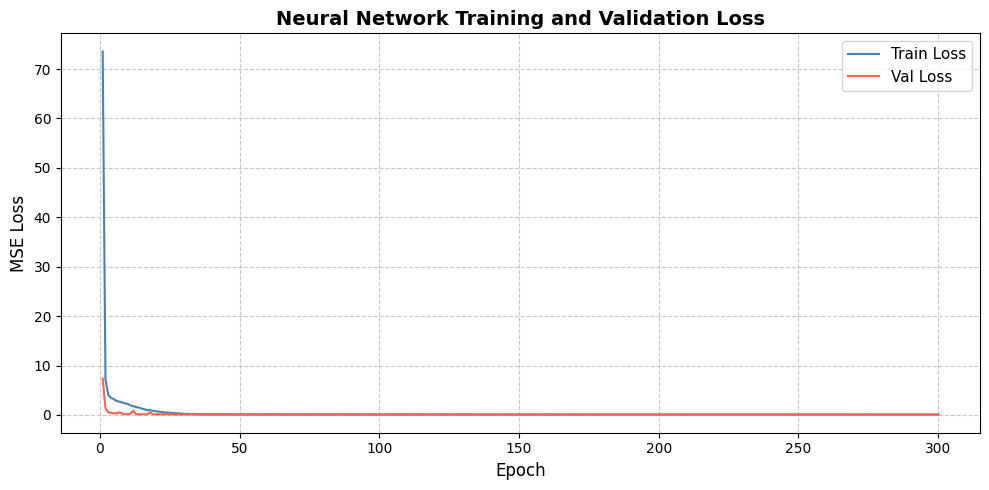

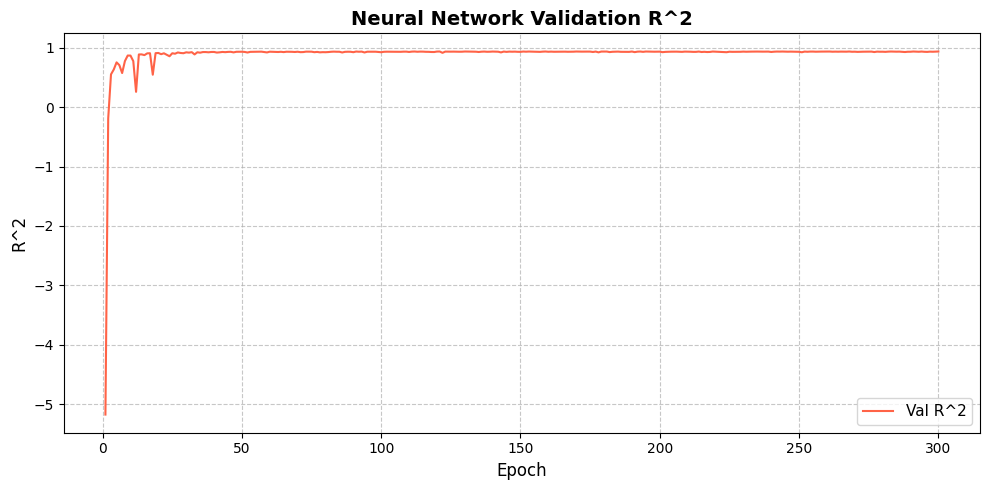

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, color='steelblue', linewidth=1.5, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses,   color='tomato',    linewidth=1.5, label='Val Loss')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Neural Network Training and Validation Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), val_r2s,   color='tomato',    linewidth=1.5, label='Val R^2')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('R^2', fontsize=12)
plt.title('Neural Network Validation R^2', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [27]:
# Retrain a fresh model on the full X_train (14,699 rows)
# The val-monitored run above confirmed the architecture and epoch count look good
torch.manual_seed(42)
model_final = MLP(input_dim=input_num).to(device)
optimizer_final = optim.Adam(model_final.parameters(), lr=0.001, weight_decay=1e-3)

X_train_t_full = torch.from_numpy(X_trained_scaled).float().to(device)
y_train_t_full = torch.from_numpy(y_train.values.copy()).float().to(device)  # .copy() avoids non-writable tensor warning
train_ds_full  = TensorDataset(X_train_t_full, y_train_t_full)
train_dl_full  = DataLoader(train_ds_full, batch_size=64, shuffle=True)

for epoch in range(num_epochs):
    model_final.train()
    for x_batch, y_batch in train_dl_full:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer_final.zero_grad()
        loss = criterion(model_final(x_batch)[:, 0], y_batch)
        loss.backward()
        optimizer_final.step()

model_final.eval()
with torch.no_grad():
    y_pred_nn_train = model_final(X_train_t_full).squeeze().cpu().numpy()
    y_pred_nn_test  = model_final(X_test_t).squeeze().cpu().numpy()

nn_train_r2 = r2_score(y_train, y_pred_nn_train)
nn_test_r2  = r2_score(y_test,  y_pred_nn_test)
nn_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_nn_test))
nn_mae_rub  = mean_absolute_error(np.exp(y_test), np.exp(y_pred_nn_test))
nn_mape     = mean_absolute_percentage_error(np.exp(y_test), np.exp(y_pred_nn_test)) * 100

print("\n=== Neural Network (MLP) ===")
print(f"Train R²:         {nn_train_r2:.4f}")
print(f"Test R²:          {nn_test_r2:.4f}")
print(f"RMSE (log):       {nn_rmse_log:.4f}")
print(f"MAE (₽):          {nn_mae_rub:,.0f}")
print(f"MAPE:             {nn_mape:.2f}%")


=== Neural Network (MLP) ===
Train R²:         0.9159
Test R²:          0.9065
RMSE (log):       0.3290
MAE (₽):          15,083,289
MAPE:             18.47%


### Neural Network (MLP) -- Findings

The network is a four-layer feedforward MLP -- 128 neurons, then 64, then 32, then a single output for Log_Price. ReLU activations after each hidden layer, Dropout(0.2) after the first two, and Adam with a small L2 penalty (weight_decay=1e-3) to keep the weights from growing unconstrained. Training followed two phases. First, X_train was split 75/25 -- 11,024 rows for gradient updates and 3,675 held out as a validation set -- to monitor loss curves and confirm the architecture and epoch count looked reasonable. Then a fresh model was retrained on the full X_train (14,699 rows) for the same 300 epochs, and all reported metrics come from that final model. The test set (3,675 rows) was never touched until the final evaluation. The full training run was accelerated on GPU (CUDA).

One thing the loss curve makes obvious: in the early epochs, training loss is noticeably higher than validation loss. This is not a signal that the model is doing better on unseen data than on its own training set -- it is an artifact of how Dropout works. During training mode, neurons are randomly zeroed out each forward pass, which degrades individual predictions and inflates the reported loss. During validation, Dropout is switched off and all neurons contribute, so the model looks stronger. By around epoch 60, the two curves converge to a more typical pattern and both losses continue declining together.

Val loss flattens out roughly in the 0.076-0.086 range after epoch 140 and stays in that band through epoch 300. The bumpiness is expected given the relatively small batch size of 64 -- each epoch samples a different subset of batches, so the reported loss has some run-to-run noise. The model is not diverging; it is just plateauing with slight variation.

Final performance lands at Test R² = 0.9065, RMSE (log) = 0.3290, MAE = 15.1M ₽, and MAPE = 18.47%. The train/test gap is small (Train R² = 0.9159 vs Test R² = 0.9065), meaning the model is not memorizing the training data. In the overall rankings, the neural network falls just below the Tuned Decision Tree on the primary metrics (RMSE log 0.329 vs 0.296, Test R² 0.907 vs 0.924), though the two are essentially tied on MAPE (18.5% vs 19.0%). It improves meaningfully on the linear models but does not reach either tuned tree model.

This is a realistic outcome for a fixed architecture at this dataset scale. With only 12 features and roughly 14,700 training examples, tree-based methods have a structural advantage -- they carve up the feature space directly through splits, while the network has to approximate those boundaries through gradient descent over 300 epochs. The jump from linear models (Test R² 0.87 → 0.91) shows the network does learn the non-linear structure in the data, but a well-tuned single tree gets there more efficiently here.

## **AdaBoost Model**

In [28]:
from sklearn.ensemble import AdaBoostRegressor

param_grid_ada = {
    'n_estimators':  [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    'loss':          ['linear', 'square', 'exponential']
}

grid_search_ada = GridSearchCV(
    estimator=AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=3), random_state=42),
    param_grid=param_grid_ada,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search_ada.fit(X_train, y_train)
ada_tuned = grid_search_ada.best_estimator_
print(f"Best params: {grid_search_ada.best_params_}")

Best params: {'learning_rate': 0.05, 'loss': 'exponential', 'n_estimators': 300}


In [29]:
y_pred_ada_train = ada_tuned.predict(X_train)
y_pred_ada_test  = ada_tuned.predict(X_test)

ada_train_r2 = r2_score(y_train, y_pred_ada_train)
ada_test_r2  = r2_score(y_test,  y_pred_ada_test)
ada_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_ada_test))
ada_mae_rub  = mean_absolute_error(np.exp(y_test), np.exp(y_pred_ada_test))
ada_mape     = mean_absolute_percentage_error(np.exp(y_test), np.exp(y_pred_ada_test)) * 100

print("=== AdaBoost (Tuned) ===")
print(f"Train R²:         {ada_train_r2:.4f}")
print(f"Test R²:          {ada_test_r2:.4f}")
print(f"RMSE (log):       {ada_rmse_log:.4f}")
print(f"MAE (₽):          {ada_mae_rub:,.0f}")
print(f"MAPE:             {ada_mape:.2f}%")

=== AdaBoost (Tuned) ===
Train R²:         0.8861
Test R²:          0.8864
RMSE (log):       0.3626
MAE (₽):          15,069,039
MAPE:             30.32%


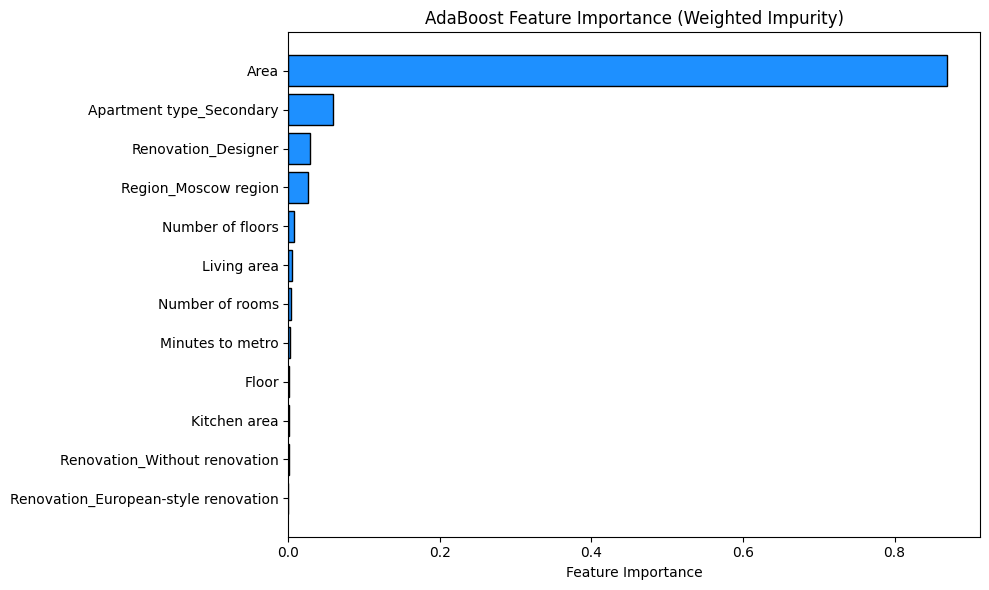

In [30]:
ada_importance_df = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': ada_tuned.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(ada_importance_df['Feature'], ada_importance_df['Importance'],
         color='dodgerblue', edgecolor='black')
plt.xlabel('Feature Importance')
plt.title('AdaBoost Feature Importance (Weighted Impurity)')
plt.tight_layout()
plt.show()

### AdaBoost (Tuned) -- Findings

GridSearchCV selected learning_rate=0.05, loss='exponential', and n_estimators=300. The exponential loss is the original AdaBoost weighting scheme -- it aggressively upweights training examples that are hard to predict, focusing each successive tree's energy on observations that prior trees got wrong. The low learning rate of 0.05 means each tree contributes only 5% of its correction, which acts as a form of shrinkage. That said, this search is narrower than it may appear: the base learner depth is fixed at max_depth=3 and only three hyperparameters were varied. n_estimators=300 landing at the top edge of the grid suggests the model could still improve with more estimators. These results are best read as the best within a constrained search rather than a fully optimized AdaBoost benchmark.

Train R² (0.8861) and Test R² (0.8864) are nearly identical, meaning the model is not memorizing the training data. The 0.0003 difference is well within the noise of a single holdout split and should not be read as a meaningful signal about regularization.

On the overall leaderboard, AdaBoost sits between the linear models and the tuned tree-based methods. Test R² of 0.886 beats OLS, Lasso, and Ridge (0.869) and comes close to the untuned Decision Tree (0.887), but falls clearly below the Tuned Decision Tree (0.924), Neural Network (0.907), and Random Forest (0.946). RMSE (log) of 0.363 follows the same pattern. MAE of 15.1M rubles is a real improvement over the linear models (~26.5M).

The MAPE of 30.3% is worth flagging -- it is worse than the linear models (28.4%) despite AdaBoost producing a lower MAE. Part of this reflects a scoring mismatch: the grid search optimized log-scale MSE, so MAPE was never directly part of the objective. A model tuned on MSE can tighten absolute errors while still making proportionally larger mistakes on cheaper listings, since MAPE weights every observation's percentage error equally regardless of price. The exponential loss compounding this by focusing corrections on high-value hard examples likely amplifies the effect.

The feature importance chart shows Area at the top, which is consistent with every other model in the notebook. These are impurity-based (MDI) importances aggregated across all 300 base trees, so the same caveat from the Random Forest section applies -- features with many effective split opportunities accumulate importance, which can overstate continuous variables relative to binary dummies. The chart is useful directionally but should not be compared directly to the Random Forest permutation importance rankings.

## **Stacking Ensemble**

In [31]:
from sklearn.ensemble import StackingRegressor
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import KFold

In [32]:
class TorchMLPRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, lr=0.001, weight_decay=1e-3, epochs=300, batch_size=64, random_state=42):
        self.lr = lr
        self.weight_decay = weight_decay
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state

    def fit(self, X, y):
        torch.manual_seed(self.random_state)
        if hasattr(X, 'values'):
            X = X.values
        X_arr = X.astype(np.float32)
        y_arr = np.array(y, dtype=np.float32, copy=True)

        self.model_ = MLP(input_dim=X_arr.shape[1]).to(device)
        opt     = optim.Adam(self.model_.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        loss_fn = nn.MSELoss()

        X_t = torch.from_numpy(X_arr).to(device)
        y_t = torch.from_numpy(y_arr).to(device)
        ds  = TensorDataset(X_t, y_t)
        dl  = DataLoader(ds, batch_size=self.batch_size, shuffle=True)

        self.model_.train()
        for _ in range(self.epochs):
            for xb, yb in dl:
                opt.zero_grad()
                loss_fn(self.model_(xb)[:, 0], yb).backward()
                opt.step()
        return self

    def predict(self, X):
        if hasattr(X, 'values'):
            X = X.values
        X_t = torch.from_numpy(X.astype(np.float32)).to(device)
        self.model_.eval()
        with torch.no_grad():
            return self.model_(X_t).squeeze().cpu().numpy()

In [33]:
base_estimators = [
    ('ridge', Pipeline([('pre', preprocess), ('m', RidgeCV(alphas=np.logspace(-3, 3, 100), cv=10))])),
    ('dt',    Pipeline([('pre', preprocess), ('m', DecisionTreeRegressor(max_depth=10, min_samples_leaf=10, min_samples_split=2, random_state=42))])),
    ('rf',    Pipeline([('pre', preprocess), ('m', RandomForestRegressor(n_estimators=300, max_depth=20, max_features='sqrt', min_samples_leaf=1, random_state=42, n_jobs=-1))])),
    ('ada',   Pipeline([('pre', preprocess), ('m', AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=3), learning_rate=0.05, loss='exponential', n_estimators=300, random_state=42))])),
    ('nn',    Pipeline([('pre', preprocess), ('nn', TorchMLPRegressor(random_state=42))])),
]

stack_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5),
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    passthrough=False,
    n_jobs=1,  # serial to avoid PyTorch/CUDA multiprocessing conflicts
)

print("Fitting stacking ensemble (this may take several minutes)...")
stack_model.fit(X_train, y_train)
print("Done.")

Fitting stacking ensemble (this may take several minutes)...
Done.


In [34]:
y_pred_stack_train = stack_model.predict(X_train)
y_pred_stack_test  = stack_model.predict(X_test)

stack_train_r2 = r2_score(y_train, y_pred_stack_train)
stack_test_r2  = r2_score(y_test,  y_pred_stack_test)
stack_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_stack_test))
stack_mae_rub  = mean_absolute_error(np.exp(y_test), np.exp(y_pred_stack_test))
stack_mape     = mean_absolute_percentage_error(np.exp(y_test), np.exp(y_pred_stack_test)) * 100

print("=== Stacking Ensemble ===")
print(f"Train R²:         {stack_train_r2:.4f}")
print(f"Test R²:          {stack_test_r2:.4f}")
print(f"RMSE (log):       {stack_rmse_log:.4f}")
print(f"MAE (₽):          {stack_mae_rub:,.0f}")
print(f"MAPE:             {stack_mape:.2f}%")

=== Stacking Ensemble ===
Train R²:         0.9897
Test R²:          0.9450
RMSE (log):       0.2523
MAE (₽):          11,848,699
MAPE:             14.93%


In [35]:
meta = stack_model.final_estimator_
base_names = [name for name, _ in base_estimators]

print("Meta-learner (RidgeCV) coefficients per base model:")
for name, w in zip(base_names, meta.coef_):
    print(f"  {name:>6}: {w:+.4f}")
print(f"intercept:  {meta.intercept_:+.4f}")
print(f"alpha:      {meta.alpha_:.4f}")

Meta-learner (RidgeCV) coefficients per base model:
   ridge: -0.0171
      dt: -0.0131
      rf: +0.9546
     ada: -0.1338
      nn: +0.2088
intercept:  +0.0246
alpha:      0.2812


### Stacking Ensemble -- Findings

The stacking ensemble combines Ridge, Tuned Decision Tree, Random Forest, AdaBoost, and the PyTorch neural network as base learners, with a RidgeCV meta-learner trained on their out-of-fold predictions. Each base estimator generates predictions through 5-fold cross-validation, so the meta-learner never sees predictions from data the base model was fit on. This eliminates the leakage that would occur if you simply trained each model on all of X_train and then stacked their predictions directly.

The results are essentially a tie with the Random Forest. Test R² of 0.9450 vs RF's 0.9464, and RMSE (log) of 0.2523 vs RF's 0.2491 -- the ensemble is marginally behind on the two primary metrics. MAPE nudges slightly in the other direction at 14.93% vs RF's 15.07%. In practical terms, there is no meaningful difference.

The meta-learner coefficients explain why. Random Forest carries a coefficient of +0.955 -- the RidgeCV meta-learner essentially concluded that RF's prediction was the signal and everything else was noise. The neural network received a modest positive weight of +0.209, suggesting it contributed a small amount of complementary signal at the edges of what RF predicts well. Ridge and the Decision Tree both received small negative weights (-0.017 and -0.013), which is the meta-learner canceling out redundant predictions from models whose errors overlap heavily with RF's. AdaBoost was penalized the most (-0.134), likely because its shallow base trees (max_depth=3) produce predictions that are both correlated with RF and noisier.

The honest takeaway here is that a single well-tuned Random Forest had already absorbed most of the learnable signal in this dataset. When you stack five models and the meta-learner puts 95% of its weight on one of them, the ensemble is not adding new information -- it is just rediscovering that RF was already doing the heavy lifting. The NN's small positive contribution (+0.21) is consistent with it capturing some smooth, linear-ish structure in the prediction surface that tree splits approximate coarsely. But that signal is small enough that the net effect on test accuracy is negligible.

In [36]:
summary = pd.DataFrame({
    'Model': [
        'OLS', 'Lasso', 'Ridge',
        'Decision Tree (Initial)', 'Decision Tree (Tuned)',
        'Random Forest', 'Neural Network', 'AdaBoost (Tuned)',
        'Stacking Ensemble'
    ],
    'Train R²': [
        train_r2_score, lasso_train_r2, ridge_train_r2,
        dt_initial_train_r2, dt_opt_train_r2, rf_train_r2,
        nn_train_r2, ada_train_r2, stack_train_r2
    ],
    'Test R²': [
        test_r2_score, lasso_test_r2, ridge_test_r2,
        dt_initial_test_r2, dt_opt_test_r2, rf_test_r2,
        nn_test_r2, ada_test_r2, stack_test_r2
    ],
    'RMSE (log)': [
        rmse_log, lasso_rmse_log, ridge_rmse_log,
        dt_initial_rmse_log, dt_opt_rmse_log, rf_rmse_log,
        nn_rmse_log, ada_rmse_log, stack_rmse_log
    ],
    'MAE (₽M)': [
        mae_rub/1e6, lasso_mae_rub/1e6, ridge_mae_rub/1e6,
        dt_initial_mae_rub/1e6, dt_opt_mae_rub/1e6, rf_mae_rub/1e6,
        nn_mae_rub/1e6, ada_mae_rub/1e6, stack_mae_rub/1e6
    ],
    'MAPE (%)': [
        mape_ols, lasso_mape, ridge_mape,
        dt_initial_mape, dt_opt_mape, rf_mape,
        nn_mape, ada_mape, stack_mape
    ]
}).set_index('Model').round({'Train R²': 4, 'Test R²': 4, 'RMSE (log)': 4, 'MAE (₽M)': 2, 'MAPE (%)': 2})

print(summary.to_string())

                         Train R²  Test R²  RMSE (log)  MAE (₽M)  MAPE (%)
Model                                                                     
OLS                        0.8599   0.8694      0.3888     26.53     28.45
Lasso                      0.8599   0.8694      0.3889     26.83     28.41
Ridge                      0.8599   0.8694      0.3888     26.47     28.41
Decision Tree (Initial)    0.9998   0.8868      0.3619     15.07     22.60
Decision Tree (Tuned)      0.9473   0.9243      0.2961     13.13     18.96
Random Forest              0.9917   0.9464      0.2491     11.59     15.07
Neural Network             0.9159   0.9065      0.3290     15.08     18.47
AdaBoost (Tuned)           0.8861   0.8864      0.3626     15.07     30.32
Stacking Ensemble          0.9897   0.9450      0.2523     11.85     14.93


### Model Comparison -- Findings

The three linear models (OLS, Lasso, Ridge) perform identically -- Test R² of 0.869, RMSE (log) of 0.389, MAPE of 28%. Regularization did not improve accuracy here because the feature set was already clean and well-conditioned. The linear models establish a strong baseline but hit a ceiling.

The Decision Tree shows the clearest before-and-after of any model in this notebook. The untuned tree memorized the training data (Train R² = 1.00) but still beat the linear models on test (0.887). After GridSearchCV selected max_depth=10 and min_samples_leaf=10, the train/test gap narrowed and test performance jumped to 0.924. That jump -- from 0.869 to 0.924 -- confirms that apartment pricing has non-linear structure that linear models cannot reach.

The Neural Network improves on the linear models (Test R² = 0.907 vs 0.869) and confirms that gradient-based learning does find the non-linear price structure in the data. However, it falls just short of the Tuned Decision Tree on the primary metrics -- RMSE (log) of 0.329 vs 0.296 and Test R² of 0.907 vs 0.924. On MAPE the two are essentially tied (18.5% vs 19.0%). With a fixed 300-epoch budget and only 12 features, the tree's direct splitting mechanism is more efficient here.

Random Forest produces the strongest test performance of any model evaluated here. Averaging 300 trees with random feature subsets pushes Test R² to 0.946, RMSE (log) to 0.249, and MAPE to 15.1%. MAE of 11.6M ₽ is less than half what the linear models produced. The train/test gap (0.992 vs 0.946) is reasonable for an ensemble -- individual trees are deep but their errors cancel out through averaging rather than amplifying.

The progression across model classes tells the main story of this project: a well-tuned linear model gets you to 87% accuracy; a neural network gets you to 91%; a pruned decision tree reaches 92%; a random forest tops out at 95%. The gains come from capturing non-linear interactions among apartment size, location, and renovation quality that a linear model has no mechanism to represent. The neural network and Tuned Decision Tree are close enough on MAPE that either could rank above the other on a different split -- the Random Forest's margin over both is more durable.

One methodological note: all models were evaluated against the same held-out test set, so the ranking reflects performance on this particular 80/20 split. Comparing multiple models on a single holdout can modestly favor whichever happened to fit that split best. The gaps between model classes here are large enough that the ordering is unlikely to change across different splits, but the reported test scores should be read as estimates rather than exact guarantees.